# 수업 내용
### 요약 : 문장을 모델 입력하는데 전처리 작업 (토큰화와 임베딩)
1. 토크나이저
2. 임베딩모델
3. 허깅페이스와 친해지기

### 업스테이지 자료에서 추가로 확인할 수 있는 내용
- Character-Level BPE 알고리즘
- 인코더, 디코더를 RNN과 LSTM 소스코드
- Attention 소스코드
- GPT2 소스코드

# 1. 토크나이저란?

- 문장을 토큰 단위로 자르고, 수로 변환해주는 툴 입니다. (토큰의 단위는 툴 마다 달라요)
  1. 문장 : "안녕하세요"
  2. 토큰 단위로 자르기 : ["안녕", "하세요"]
  3. 각 토큰을 수로 변환 : [8192, 91352]


# 2. 토크나이저를 쓰는 이유
- 모델의 입력값은 수 잖아요?
  - y = wx + b 에서 x 값 !

<br/>

- 문장도 입력 데이터로 쓰려면, 문장을 수로 바꿔야합니다.
  - 그런데.... '문장' 자체가 고유 값을 가진 수로 바꾸기가 쉽지 않습니다.
    - "안녕하세요" ----> 582번
    - "치킨맛있어" ----> 582번 (이렇게 되면 안됩니다.)
  - 모든 문장을 수로 치환할 수는 없을 겁니다. 경우의 수가 무한대예요
  - 그래서 문장을 특정 단위로 자른 후, 작은 단위를 수로 만듭니다.

<br/>

- 우리는 조금 있다가 이런 판별기 사용해볼겁니다. (문장 감정 판별기)
  - "난행복해" ---> 긍정
  - "우울해서빵샀어" ---> 부정
  - "헤어졌어" ---> 부정
  - 추론할때 **입력 문장을 토크나이저를 거쳐서 수 List로 변환** 후, 모델에 추론시킬겁니다.
    - 문장 자체를 모델에 입력시킬수가 없으니까요.

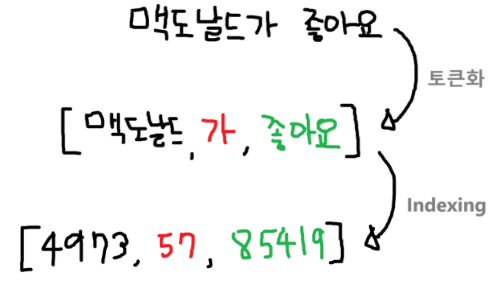

# 3. 토크나이저 기본 원리

### 토크나이저 동작 원리
  - 토크나이저
    - 미리 완성되어있는 Vocabulary(사전)을 준비합니다. (**다운로드 받습니다.**)
      - 이 Vocabulary에는 (단어 : Index 번호) 형태로 저장되어 있습니다.
      - 각 단어는 토큰이라고 부르고, 각각 Index 번호가 있습니다.
    
    - 입력 데이터를 Vocabulary에 있는 단어들(토큰)으로 구성될 수 있도록 합니다.
      - 입력 데이터를 Vocabulary를 참고하여 토큰의 Index 번호로 변환합니다.
      - 예시: "안녕하세요" --> ["안녕", "하세요"] --> [8192, 91352]

<br/>

### Vocabulary는 어떻게 만드나요?
  1. 대규모 Text 데이터를 이용하여, 많이 등장하는 글자 or Byte를 알아 낼겁니다.
  2. 데이터를 글자 or Byte 데이터 단위로 분할한 후에, 자주 함께 등장하는 조합을 찾아냅니다.
  3. 이런 글자조합 or Byte조합들을 Vocabulary의 토큰으로 등록시키고 Index 번호를 부여합니다
    
<br/>

### Vocabulary를 학습할 때 쓰이는 대표적인 알고리즘
  - 사전을 만드는 작업을 **Tokenizer Training** 이라고 하는데요,
  - Vocabulary Training 알고리즘은 대표적으로 2개가 있습니다.
    1. Word Piece
      - 글자 단위로 분할 후, 자주 함께 등장하는 **글자 조합**을 토큰으로 선정합니다.
      - 빈도를 활용한 점수를 측정하여 좋은 조합을 찾아냅니다.
    2. Byte-Level BPE
      - Byte 단위로 분할 후, 자주 함께 등장하는 **Byte 조합**을 토큰으로 선정합니다.
      - 빈도가 높은 조합을 찾아냅니다.

<br/>

### 수업내용은 다음과 같습니다.
1. Word Piece 알고리즘으로 만들어진 "BERT 토크나이저" 실습
2. Byte-Level BPE 알고리즘으로 만들어진 "Byte-Level 토크나이저" 실습
3. 최신 모델 토크나이저 살펴보기

# 4. 토큰화 해보기

### BERT 토크나이저 실습

- 완성된 토크나이저 툴을 사용해볼겁니다.
- 완성된 툴, 모델들을 Github처럼 Open Source로 공개하는 사이트가 있습니다. 바로 **허깅페이스** 입니다.
  - AI 개발자들이 만든 모델을 세상에 알리고 싶을 때, 이 허깅페이스에 올립니다.
  - 여기서 다운로드 수가 많거나 "좋아요" 버튼 많이 받으면 유명해집니다.
- **허깅페이스**의 공식 Library인 **transformers**(트렌스포머스)를 이용하면 허깅페이스에 있는 툴, 모델을 쉽게 다운로드 & 사용 가능합니다.

<br/>

- BERT는 유명한 LLM 모델입니다. BERT에 대해서는 조금 후에 자세히 설명드릴게요.
  - BERT 모델에서 사용된 토크나이저가 있습니다.
    - WordPiece 알고리즘으로 Vocabulary가 만들어졌습니다.
    - BERT 모델이 사용했던 토크나이저라고 해서 **BERT 토크나이저**라고 부릅니다
  - **오해하시면 안돼요. BERT는 토크나이저가 아니라 유명한 언어 모델입니다.**
    - 지금 설명드리는것은 BERT에서 쓰인 토크나이저 입니다
  - BERT 토크나이저의 출력 결과는 ##이 자주 등장합니다.
    - "##하다" 처럼 "##"이 자주 나올건데, 이건 앞에 접두사가 존재한다는 뜻합니다. 앞에 다른 글자가 붙는 다는 것이죠.


In [1]:
# 로컬에서는 설치 필요. 최초 1번 실행
#!pip install transformers==4.57.3

from transformers import AutoTokenizer

# 아래는 모델 ID 입니다. (GIthub 의 Repository ID 값으로 주소로 비유할 수 있어요.)
# 4개 중에 어떤 모델의 토크나이저가 한국어와 영어를 가장 잘 인식하는지 맞춰보세요.

model_id = "google-bert/bert-base-multilingual-cased"    # 1. BERT 언어모델
#model_id = "klue/bert-base"                  # 2. 한국어 잘 되는, 허깅페이스에서 인기많은 BERT 기반 모델1
#model_id = "kykim/bert-kor-base"             # 3. 한국어 잘 되는, 허깅페이스에서 인기많은 BERT 기반 모델2
#model_id = "gpt2"                            # 4. GPT2 언어모델 (<---- BERT 토크나이저 아님)

tokenizer = AutoTokenizer.from_pretrained(model_id) #모델 안에 들어있는 "학습된 Vocabulary"를 사용하여 토큰화를 할겁니다.

korean = "여러분 식사는 즐겁게 하셨나요? 저는 맥도날드에 다녀왔어요. 오늘도 행복한 하루되세요."
english = "Did everyone enjoy your meal? I went to McDonald's. Have a happy day today as well."

# 토큰화
tokens_kor = tokenizer.tokenize(korean)
tokens_eng = tokenizer.tokenize(english)

# 인덱싱
ids_kor = tokenizer.convert_tokens_to_ids(tokens_kor)
ids_eng = tokenizer.convert_tokens_to_ids(tokens_eng)

print('[한글]')
print(f'원문 : {korean}')
print(f'토큰화 : {tokens_kor}')
print(f'인덱싱 : {ids_kor}')

print()
print()

print('[영어]')
print(f'원문 : {english}')
print(f'토큰화 : {tokens_eng}')
print(f'인덱싱 : {ids_eng}')

[한글]
원문 : 여러분 식사는 즐겁게 하셨나요? 저는 맥도날드에 다녀왔어요. 오늘도 행복한 하루되세요.
토큰화 : ['여러', '##분', '식', '##사는', '즐', '##겁', '##게', '하', '##셨', '##나', '##요', '?', '저', '##는', '맥', '##도', '##날', '##드', '##에', '다', '##녀', '##왔', '##어', '##요', '.', '오', '##늘', '##도', '행', '##복', '##한', '하', '##루', '##되', '##세', '##요', '.']
인덱싱 : [30085, 37712, 9486, 64379, 9703, 118626, 14153, 9952, 119050, 16439, 48549, 136, 9663, 11018, 9259, 12092, 41919, 15001, 10530, 9056, 50814, 119163, 12965, 48549, 119, 9580, 118762, 12092, 9966, 70915, 11102, 9952, 35866, 118800, 24982, 48549, 119]


[영어]
원문 : Did everyone enjoy your meal? I went to McDonald's. Have a happy day today as well.
토큰화 : ['Did', 'everyone', 'enjoy', 'your', 'me', '##al', '?', 'I', 'went', 'to', 'McDonald', "'", 's', '.', 'Have', 'a', 'happy', 'day', 'today', 'as', 'well', '.']
인덱싱 : [50133, 48628, 84874, 20442, 10911, 10415, 136, 146, 13446, 10114, 32052, 112, 187, 119, 24852, 169, 54214, 11940, 18745, 10146, 11206, 119]


- 위 코드에 써있는 모델 3개는, 그냥 허깅페이스 사이트에서 Most downloads 수가 높은 언어 모델 중에 고른겁니다.

In [11]:
# 허깅페이스에서 받은 모델이 실제 저장된 경로 확인하는 방법
!ls -R ~/.cache/huggingface/hub | head -n 50

# 특정 모델 폴더만 확인하는 방법
!ls ~/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased/

/home/ssafy/.cache/huggingface/hub:
models--google-bert--bert-base-multilingual-cased
models--gpt2
models--intfloat--e5-small-v2
models--klue--bert-base

/home/ssafy/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased:
blobs
refs
snapshots

/home/ssafy/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased/blobs:
2ba5de7675473164e07f3b3531748c9a6f113a2c
420b0fc31334c64ddf53cc3e9222a6d4c59d0cae
b122e74db13b415ea824c074da33c1c44f0d13a3
e837bab60a5d204e29622d127c2dafe508aa0731

/home/ssafy/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased/refs:
main

/home/ssafy/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased/snapshots:
3f076fdb1ab68d5b2880cb87a0886f315b8146f8

/home/ssafy/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased/snapshots/3f076fdb1ab68d5b2880cb87a0886f315b8146f8:
config.json
tokenizer.json
tokenizer_config.json
vocab.txt

/home/ssafy/.cache/huggingface/hub/models--gpt2:


- 여기서 잠깐 보고 알고 넘어가야할 것이 있습니다.
  - BERT 모델이 뭔지?

### BERT 모델?
  - Transformer 라는 모델 구조를 응용하여 매우 우수한 언어 모델을 만들 수 있다는 것을... 세상에 알린 모델입니다. (by Google)
    - Transformer는 이전 강의에서 잠깐 그림으로 등장했었죠?

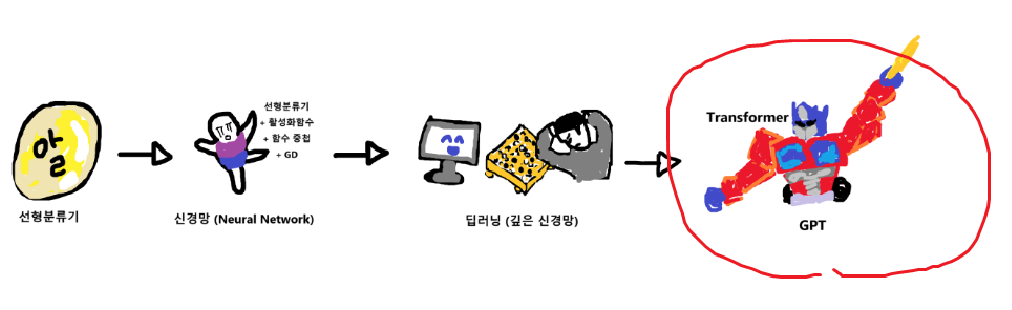

  - 이 시작이 바로 BERT 언어모델 입니다.
  - NLP(자연어처리) 벤치마크 점수의 신기록을 압도적으로 전부 갈아치웠어요.
    - NLP : 컴퓨터가 인간의 말(자연어)을 이해하고 분석하는 AI 분야의 공식 명칭
    - 스피드 스케이팅의 이상화,
    - 피겨 스케이팅의 김연아가 있으면
    - NLP의 BERT 가 있는 것이죠.
      - 참고자료 : https://namu.wiki/w/%EC%9D%B4%EC%83%81%ED%99%94
  
<br>

### BERT 모델 관련 Q&A
  - Q. 지금도 쓰는 언어모델인가요?
  - A. 아니요. LLM 역사에선 중요하지만 지금은 잘 안쓰입니다.~

<br/>

  - Q. 그럼 "BERT 토크나이저" 는 자주 쓰이나요?
  - A. 아니요. 토크나이저 역사에선 중요하시만, 지금은 잘 안쓰입니다~.

<br/>

  - Q. 그럼 무슨 토크나이저를 요즘 많이쓰나요?
  - A. Byte-Level BPE 토크나이저를 많이 씁니다.
   GPT, 클로드, 제미나이 에서도 쓰는 방식이죠.

<br/>

  - Q. 그럼 수업을 왜 "BERT 토크나이저"로 했나요? Byte-Level BPE 로 안하고
  - A. BERT 토크나이저는 한글 토큰화 결과가 잘 보여요. 글자 단위로 쪼개져있어서요.<br/>아까 GPT2는 한글 잘 안보였죠? Byte 단위로 쪼개져서 결과가 잘 안보입니다. 그뿐입니다 ^^; (BERT 도 소개할겸요)

<br />

### 허깅페이스에서 Vocabulary 살펴보기
  - 오픈소스계 Github이 있다면, AI 모델계 오픈소스는 "허깅페이스"가 있습니다.
  - 아래 이모지 이름이 "허깅페이스" 라고 합니다.
    - 10대 감성 챗봇 앱을 만들었다가, AI 오픈소스 플랫폼으로 전환했다고 하네요.

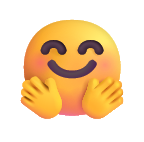

- 한번 들어가봅시다. (구글링 : 허깅페이스)
  - https://huggingface.co/

<br/>

- 가입도 미리 해서 로그인합시다.
  - 나중에 수업때 사용해야해서, 미리 가입해둡시다.
  - 메일 인증도 미리 해주세요.

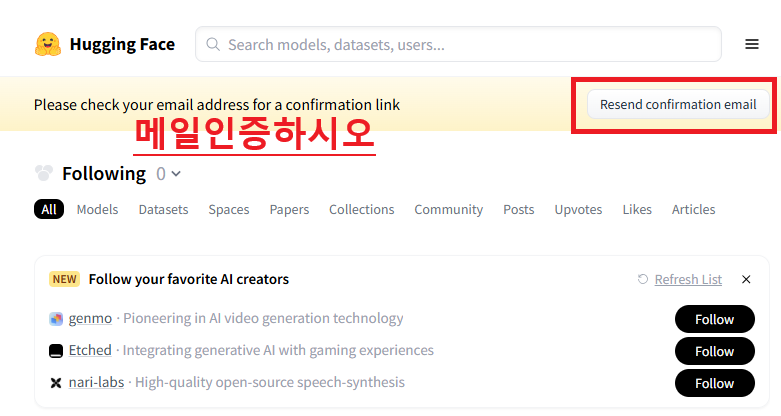

- 첫 메뉴에서 "Models" 메뉴를 눌러봅니다.
  - 다양한 모델 (언어모델 등) 이 있습니다.

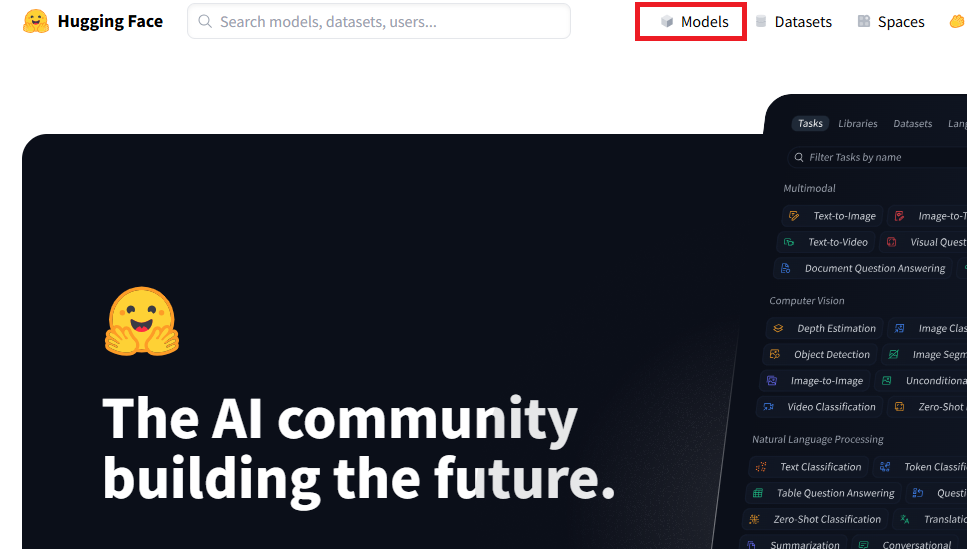

- 아래 이미지 처럼 BERT 언어모델을 검색해봅시다.
  - 아까 사용해봤던 모델도 만나볼 수 있습니다.

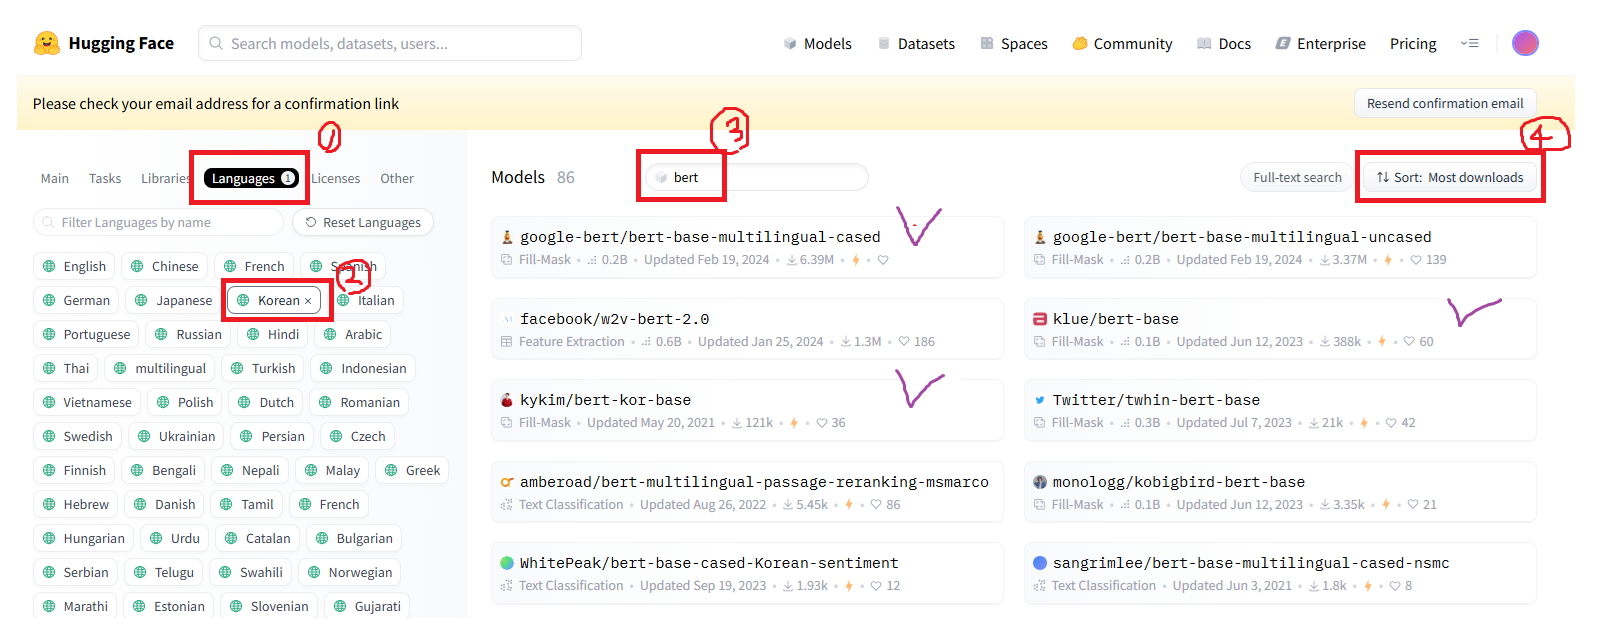

- BERT 모델에다가 한국어를 추가 학습시킨 klue/bert-base 모델을 클릭합니다.

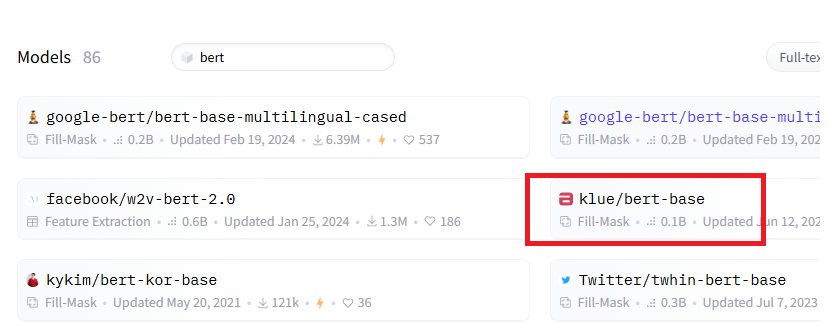

- 여기가 github의 repository 첫 페이지에 해당되는 곳입니다.
  - Model card라고 있는데, github처럼 README.md 파일이 보여지는 곳입니다.
  - 모델에 대한 설명들을 적어두곤 합니다.

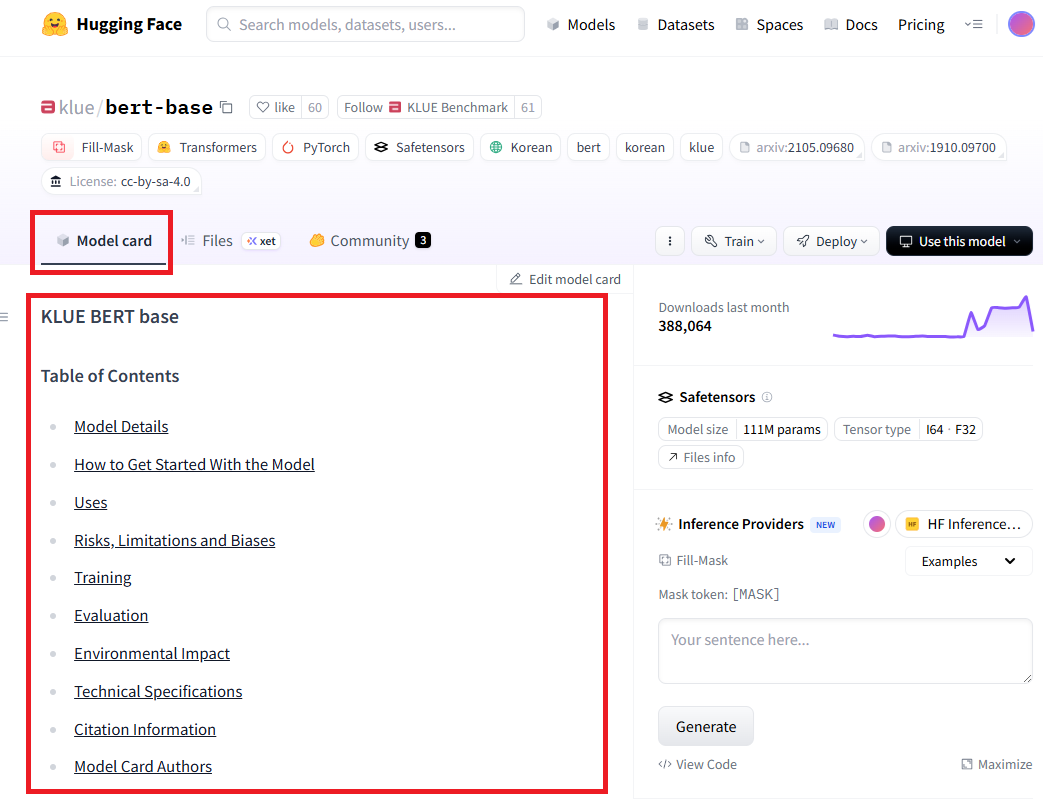

- 이제 Files를 눌러봅시다.
  - README.md 파일이 보이네요. 이 내용이 모델 카드에 보여집니다.
  - pytorch_model.bin
    - 저번 수업에 model.pth 파일 저장했던것 기억나시죠? 그 파일입니다.
    - PyTorch 에서는 확장자를 .pth를 권장하지만 허깅페이스는 .bin 을 권장합니다.
    - 그냥 확장자만 .pth 로 바꿔도 잘 동작합니다.
  - vocab.txt
    - 토크나이저의 정의 기억나실까요?
      - 미리 완성되어있는 **Vocabulary**(사전) 에서, 토큰이 있는 Index 번호로 변환하는 것
      - 그 Vocabulary가 여깃습니다.
      - 허깅페이스 예전에는 vocab.txt를 두는 것을 권장했는데, 지금은 사용 안합니다.
      - 구버전 호환을 위해 vocab.txt파일이 이렇게 있는 경우가 있습니다.
  - tokenizer.json
    - vocab.txt 대신 tokenizer.json 파일, 이걸 사용합니다.
    - **여기 안에 vocab.txt 파일 내용이 다 들어있어요.**
    - 추가적으로 토큰화 할때 설정값들도 함께 들어있습니다.

- tokenizer.json 파일 다운로드 받고 열어봅시다.

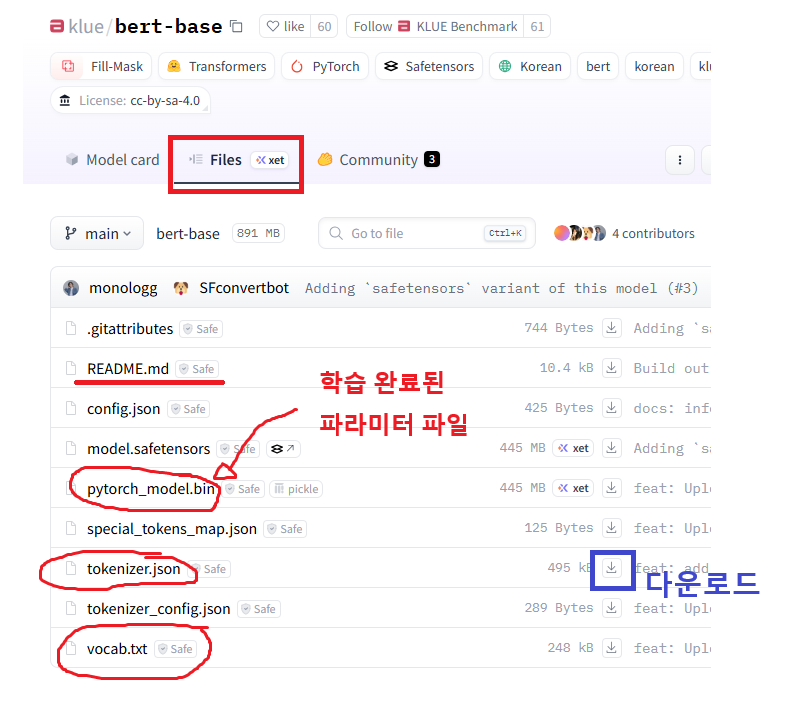

- vscode로 열고 아래 버튼을 눌러줍시다.

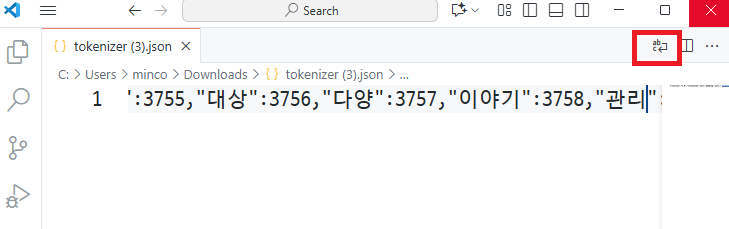

- JSON파일에서 직접 **19865 번** index를 가진 토큰을 찾아봅시다.
  - 제가 좋아하는 겁니다.

- 이번에 다시 토크나이저 결과 코드를 살펴보겠습니다.
  - 19865 번이 잘 보이죠?

In [12]:
from transformers import AutoTokenizer

model_id = "klue/bert-base"  #한국어 잘 되는, 허깅페이스에서 인기많은 BERT 기반 모델

tokenizer = AutoTokenizer.from_pretrained(model_id)

korean = "저는 맥도날드에 다녀왔어요."
english = "I went to McDonald's."

# 토큰화
tokens_kor = tokenizer.tokenize(korean)
tokens_eng = tokenizer.tokenize(english)

# 인덱싱
ids_kor = tokenizer.convert_tokens_to_ids(tokens_kor)
ids_eng = tokenizer.convert_tokens_to_ids(tokens_eng)

print('[한글]')
print(f'원문 : {korean}')
print(f'토큰화 : {tokens_kor}')
print(f'인덱싱 : {ids_kor}')


print()
print()

print('[영어]')
print(f'원문 : {english}')
print(f'토큰화 : {tokens_eng}')
print(f'인덱싱 : {ids_eng}')

[한글]
원문 : 저는 맥도날드에 다녀왔어요.
토큰화 : ['저', '##는', '맥도날드', '##에', '다녀왔', '##어요', '.']
인덱싱 : [1535, 2259, 19865, 2170, 11765, 10283, 18]


[영어]
원문 : I went to McDonald's.
토큰화 : ['I', 'we', '##nt', 'to', 'Mc', '##D', '##on', '##ald', "'", 's', '.']
인덱싱 : [45, 23638, 30062, 7052, 20174, 2134, 3827, 22524, 11, 86, 18]


- 아래와 같이 tokenizer.decode() 함수를 이용하여 id 값을 원래 토큰 문자열로 복원할 수 있습니다.

In [13]:
from transformers import AutoTokenizer

model_id = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

token = tokenizer.decode([19865])

print(token)


맥도날드


# 4. Byte-Level BPE 토크나이저
### Byte-Level BPE 소개
  - BERT 토크나이저(Word Piece) 보다 더 대세인 Byte-Level BPE를 살펴볼 시간입니다.
    - 대규모 LLM 은 죄다 이 Byte-Level BPE(Byte Pair Encoding)를 쓰고 있습니다.

  - Byte-Level BPE는 정확히 Vocabulary를 생성하는 알고리즘 입니다.
    - 이 알고리즘으로 "Vocabulary"를 만드는 겁니다
    - 이렇게 만든 Vocabulary를 사용하는 토크나이저를 **Byte-Level BPE 토크나이저**라고 합니다
      - 참고로 Word Piece 알고리즘으로 만든 Vocabulary를 사용한 토크나이저를 BERT 토크나이저라고 합니다.

  - Byte-Level BPE 알고리즘은 '단어' 기준이 아니라 'Byte' 기준으로 동작합니다.
    - Word Piece 알고리즘은 자주 사용되는 연속 글자들을 찾아, 합쳐 토큰이 됩니다.
    - Byte-Level BPE는 자주 사용되는 연속 Byte 값을 합쳐서 토큰화 합니다.    
  
  - 영어는 한 글자당 1 Byte 이고, 한글, 중어와 일어는 3 Byte, 이모지는 4 Byte입니다.
    - AI에서는 UTF-8 유니코드을 사용하기에, UTF-8 기준 크기입니다.
    - BERT 토크나이저는 영어에 맞춰 만들어져 있어, 한글에 사용하기엔 별도 학습이 필요합니다.
    - Byte-Level BPE를 쓰면 모든 언어에서 잘 동작되어 별도 학습이 없어도 됩니다. 그래서 대규모 모델에는 죄다 Byte-Level BPE 가 사용됩니다.

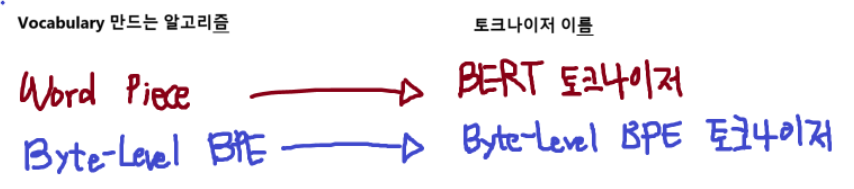

### Byte-Level BPE 토크나이저 동작시켜보기
- 아까 GPT2 모델에서 쓰인 토크나이저를 동작시켜봤는데요.
  - GPT2의 토크나이져가 Byte-Level BPE 토크나이저 입니다.

In [14]:
from transformers import AutoTokenizer

model_id = "gpt2" # GPT2 언어모델 (<---- BERT 토크나이저 아님, Byte-Level BPE 토크나이저)

tokenizer = AutoTokenizer.from_pretrained(model_id)

korean = "여러분 식사는 즐겁게 하셨나요? 저는 맥도날드에 다녀왔어요. 오늘도 행복한 하루되세요."
english = "Did everyone enjoy your meal? I went to McDonald's. Have a happy day today as well."

# 토큰화
tokens_kor = tokenizer.tokenize(korean)
tokens_eng = tokenizer.tokenize(english)

# 인덱싱
ids_kor = tokenizer.convert_tokens_to_ids(tokens_kor)
ids_eng = tokenizer.convert_tokens_to_ids(tokens_eng)

print('[한글]')
print(f'원문 : {korean}')
print(f'토큰화 : {tokens_kor}')
print(f'인덱싱 : {ids_kor}')

print()
print()

print('[영어]')
print(f'원문 : {english}')
print(f'토큰화 : {tokens_eng}')
print(f'인덱싱 : {ids_eng}')

[한글]
원문 : 여러분 식사는 즐겁게 하셨나요? 저는 맥도날드에 다녀왔어요. 오늘도 행복한 하루되세요.
토큰화 : ['ì', 'Ĺ', '¬', 'ë', 'Ł', '¬', 'ë', '¶', 'Ħ', 'Ġì', 'ĭ', 'Ŀ', 'ì', 'Ĥ¬', 'ë', 'Ĭ', 'Ķ', 'Ġì', '¦', 'Ĳ', 'ê', '²', 'ģ', 'ê', '²', 'Į', 'Ġ', 'íķ', 'ĺ', 'ì', 'ħ', '¨', 'ë', 'Ĥ', 'ĺ', 'ì', 'ļ', 'Ķ', '?', 'Ġì', 'ł', 'Ģ', 'ë', 'Ĭ', 'Ķ', 'Ġë', '§', '¥', 'ë', 'ı', 'Ħ', 'ë', 'Ĥ', 'ł', 'ë', 'ĵ', 'ľ', 'ì', 'Ĺ', 'Ĳ', 'Ġë', 'ĭ', '¤', 'ë', 'ħ', 'Ģ', 'ì', 'Ļ', 'Ķ', 'ì', 'ĸ', '´', 'ì', 'ļ', 'Ķ', '.', 'Ġì', 'ĺ', '¤', 'ë', 'Ĭ', 'ĺ', 'ë', 'ı', 'Ħ', 'Ġ', 'í', 'ĸ', 'ī', 'ë', '³', 'µ', 'íķ', 'ľ', 'Ġ', 'íķ', 'ĺ', 'ë', '£', '¨', 'ë', 'Ĳ', 'ĺ', 'ì', 'Ħ', '¸', 'ì', 'ļ', 'Ķ', '.']
인덱싱 : [168, 245, 105, 167, 253, 105, 167, 114, 226, 23821, 233, 251, 168, 8955, 167, 232, 242, 23821, 99, 238, 166, 110, 223, 166, 110, 234, 220, 47991, 246, 168, 227, 101, 167, 224, 246, 168, 248, 242, 30, 23821, 254, 222, 167, 232, 242, 31619, 100, 98, 167, 237, 226, 167, 224, 254, 167, 241, 250, 168, 245, 238, 31619, 233, 97, 167, 227, 222, 168, 247, 242, 168, 244, 112

- 영어는 잘 되는데, 한글 지원이 약해요.
- 잘 보시면 Ġ 글자가 많이 껴있습니다.
  - BERT 토크나이저의 #이 들어간 토큰은 접미사였는데 이건 다릅니다.
  - **Ġ 은 띄어쓰기**를 뜻합니다.

# Byte-Level BPE 토크나이저 Q&A
- **Q. Byte-Level BPE를 그냥 "BPE" 라고 부르면 안되나요?**
- A. BPE가 혼란스럽게도.. 2개로 나눠졌습니다. <br/>
  Character-Level BPE 하고 Byte-Level BPE 로 나뉘었습니다. <br/>
  그냥 BPE라고 하면 Character-Level BPE(또는 CharBPE) 일수도 아닐 수 도 있습니다. <br/>
  따라서 Byte-Level BPE(또는 BBPE) 라고 명시해야합니다.

<br/>

- **Q. Sentence Piece 토크나이저가 있던데 이건 뭐예요?**
- A. 유명한 토크나이저 프레임워크이자 Library 입니다. <br/>
여러 토크나이저 알고리즘을 지원하고, 토크나이저 작업에 필요한 기능들을 통합해두었습니다.<br/>
Byte-Level BPE가 대세가 되기 전, 한국어, 일본어, 중국어의 토크나이저로 많이 사용된 프레임워크입니다.

# 5. 최신 모델의 토크나이저 살펴보기
- BERT보다는 근래 만들어진 모델의 토크나이저를 살펴보겠습니다.~
- 아무거나 해도 되지만, DeepSeek 를 기준으로 하겠습니다.
  - 최신 모델을 하나 선택해봅시다.
  - 아래 이미지와 다른 버전을 선택해도 됩니다.

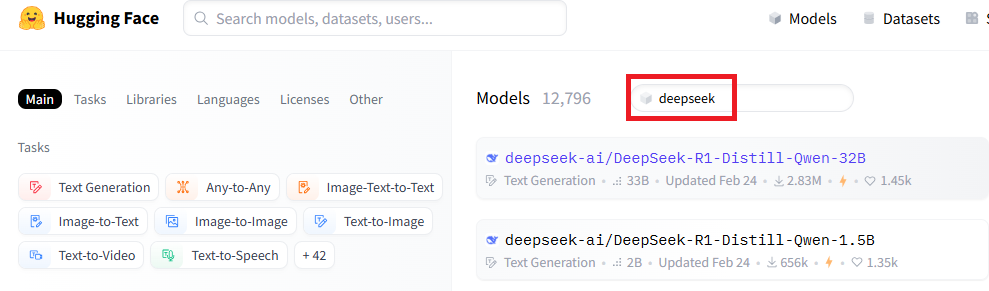

- Files 탭을 누르고, tokenizer.json 파일을 다운로드 받습니다.

<br/>

- 거대한 용량의 모델 파라미터 파일도 한번 구경하고 넘어갑시다.
  - 허깅페이스 예전 권장사항 : model.bin 파일
  - 허깅페이스 23년 이후 권장사항 : model.safetensors 파일
    - 심어진 악성코드를 실행하지 못하도록 보안이 더 강화되었다고 합니다.

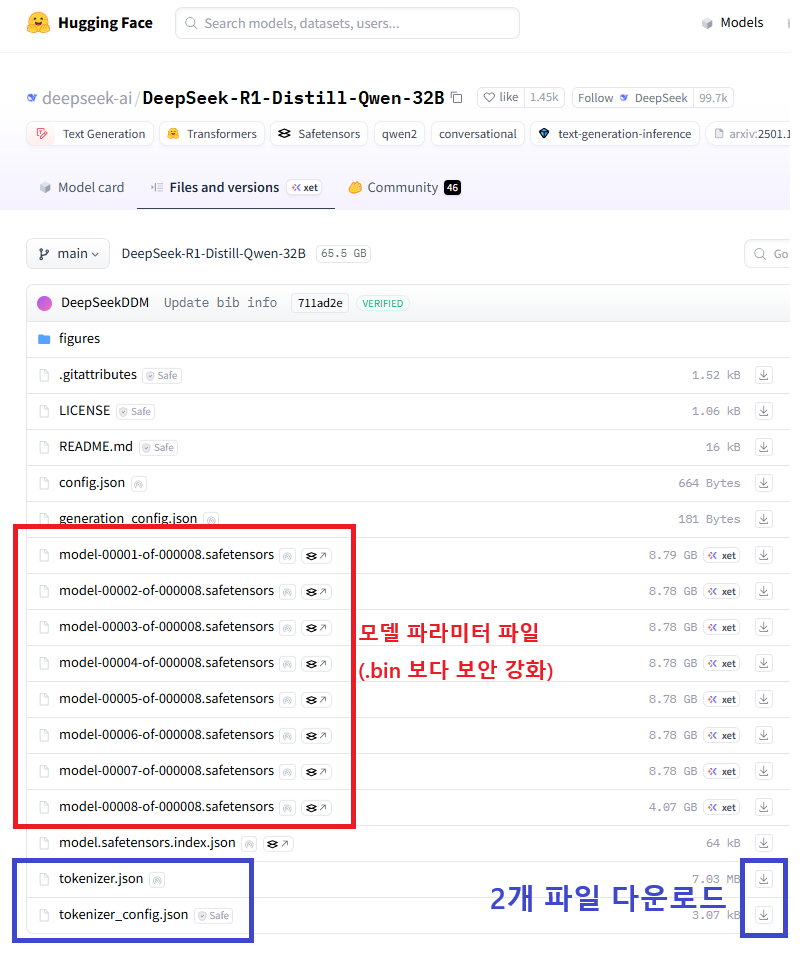

- 폴더를 하나 만들고, 다운로드 받은 2개 파일을 넣어주세요.
- 파일명 더블체크 해주세요!
  - 폴더명 : **tokenizer_deepseek**
    - 파일명 1 : tokenizer_config.json
    - 파일명 2 : **tokenizer.json**

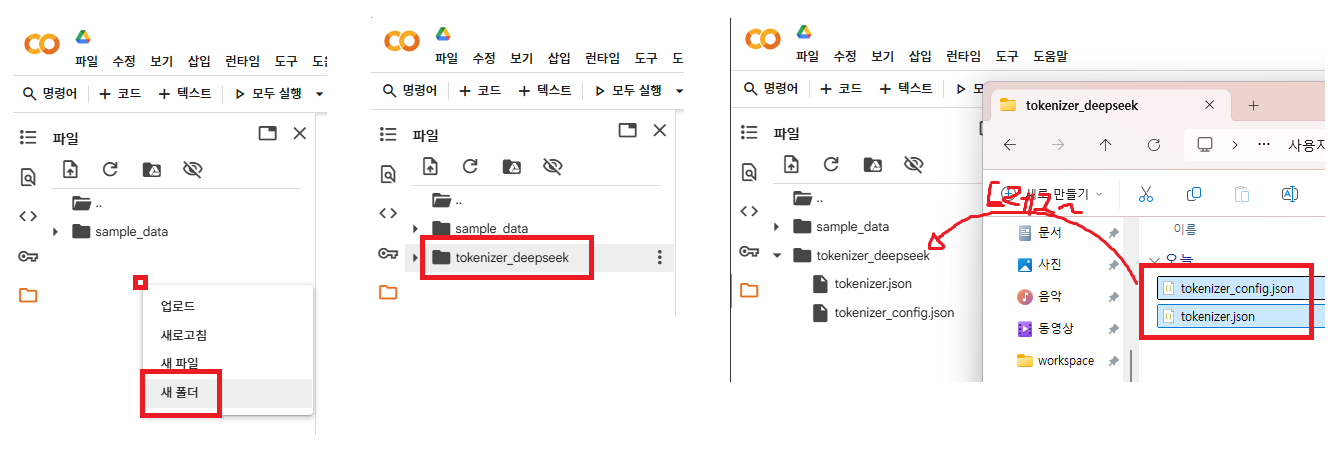

- 2개 파일은 각각 다음과 같습니다.
  - tokenizer.json : 토크나이저 사전과 핵심 옵션들
  - tokenizer_config.json : 추가 옵션들 (없어도 Default 옵션으로 토크나이저 동작 함)

- 2개 폴더를 복사하면, 아래 코드가 잘 동작됩니다.
  - 이렇게 tokenizer 관련 json 파일만 있으면 토크나이저가 잘 동작됩니다.

In [15]:
from transformers import AutoTokenizer

#model_id = "klue/bert-base" # 한국어 잘 되는, 허깅페이스에서 인기많은 BERT 기반 모델
#tokenizer = AutoTokenizer.from_pretrained(model_id)

# 폴더를 지정해주면, 알아서 토큰화 준비를 합니다.
tokenizer = AutoTokenizer.from_pretrained("./tokenizer_deepseek")

korean = "저는 맥도날드에 다녀왔어요."
english = "I went to McDonald's."

# 토큰화
tokens_kor = tokenizer.tokenize(korean)
tokens_eng = tokenizer.tokenize(english)

# 인덱싱
ids_kor = tokenizer.convert_tokens_to_ids(tokens_kor)
ids_eng = tokenizer.convert_tokens_to_ids(tokens_eng)

print('[한글]')
print(f'원문 : {korean}')
print(f'토큰화 : {tokens_kor}')
print(f'인덱싱 : {ids_kor}')

print()
print()

print('[영어]')
print(f'원문 : {english}')
print(f'토큰화 : {tokens_eng}')
print(f'인덱싱 : {ids_eng}')

[한글]
원문 : 저는 맥도날드에 다녀왔어요.
토큰화 : ['ìłĢ', 'ëĬĶ', 'Ġë§', '¥', 'ëıĦ', 'ëĤł', 'ëĵľ', 'ìĹĲ', 'Ġëĭ¤', 'ëħĢ', 'ìĻĶ', 'ìĸ´ìļĶ', '.']
인덱싱 : [126781, 16560, 32985, 98, 47985, 129378, 29346, 19391, 49367, 132751, 127621, 131355, 13]


[영어]
원문 : I went to McDonald's.
토큰화 : ['I', 'Ġwent', 'Ġto', 'ĠMcDonald', "'s", '.']
인덱싱 : [40, 3937, 311, 30914, 594, 13]


- Byte-Level BPE는 토큰화된 완성된 글자를 이상한 문자로 보여줍니다.
  - 토큰화된 값을 Byte-Level BPE 내부에서 사용하는 문자코드로 변환한겁니다.
    - OS, Web 에서 사용하는 문자코드 : UTF-8 (유니코드)
    - Byte-Level BPE가 내부적으로 사용하는 문자코드 : "Customize한 Latin-1" 그리고 UTF-8
  - 출력된 깨진 문자는 **Byte-Level BPE가 사용하는 문자코드를 UTF-8**으로 출력해서 그렇습니다.

<br />

- 한글 토큰값을 제대로 보려면, 토크나이저 Library에서 Decode 함수를 사용하면 됩니다.
  - 그런데 Byte 단위로 짤려서 만들어진 토큰은.. 깨져서 보일 수 있습니다.

In [16]:
# BPE의 디코딩 (토큰값을 UTF-8 로 복원)
for id in ids_kor: # 한글
  decoded = tokenizer.decode([id])
  print(decoded, end=" ")

print()
for id in ids_eng: # 영어
  decoded = tokenizer.decode([id])
  print(decoded, end=" ")

저 는  � � 도 날 드 에  다 녀 왔 어요 . 
I  went  to  McDonald 's . 

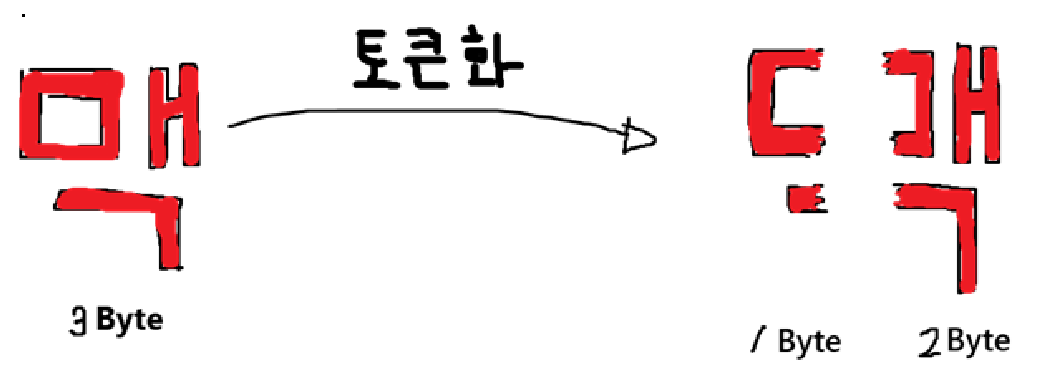

#

# 6. 정리! 토크나이저
- 토크나이저는 앞으로 LLM 모델을 사용할때 마다 접하게되는 툴입니다.
- Tokenizer Training 에 사용되는 대표적인 2개의 알고리즘이있습니다.
  - Word Piece 알고리즘 : 글자단위 분해 후, 자주 연속으로 사용되는 글자들을 모아 토큰으로 등록
  - Byte-Level BPE 알고리즘 : Byte단위 분해 후, 자주 연속으로 사용되는 Byte들 모아 토큰으로 등록
- 어떤 알고리즘을 사용하느냐에 따라 토크나이저가 2개로 분류됩니다.
  - BERT 토크나이저 : Word Piece 알고리즘으로 만든 Vocabulary를 사용하는 토크나이저
  - Byte-Level BPE 토크나이저 : Byte-Level BPE 알고리즘으로 만든 Vocabulary를 사용하는 토크나이저
- 둘 중에 주로 Byte-Level BPE 토크나이저를 주로 사용합니다


# 7. 임베딩 모델 개념 이해하기

### 임베딩 모델이란?
- **단어**를 "의미공간"이라는 벡터 공간에 **맵핑**해주는 **모델** 입니다.
  - 단어를 벡터 값으로 바꿔주는 것입니다.
    - 어느 공간의 벡터? : 바로 "의미공간" 이라는 세계의 벡터값입니다.
    - 의미 공간은, 같은 의미를 가진 값은 비슷한 벡터값을 갖게해주는 공간입니다.
  - 모델이니까, 학습을 통해 만든 것이겠죠?
    - 주로 Transformer 라는 구조의 모델로 만들어집니다.

<br/>

- 아래 그림을 이해해봅시다.
  - 왼쪽은 토크나이징(토큰화)를 하고, ID 값을 예시로 적은 것이고
  - 오른쪽은 "의미공간" 이라는 공간에 맵핑한겁니다.

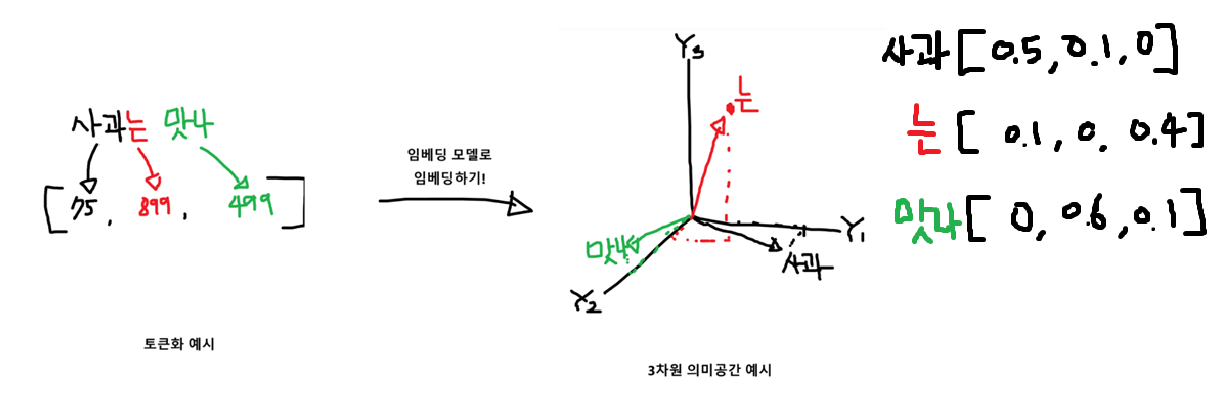

- 이후에 "애플은 짱 맛잇지" 라는 입력이 들어왔다고 가정합니다.

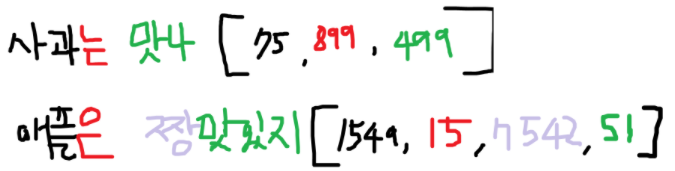

- 임베딩 모델에, 토큰의 ID값을 입력으로 넣으면 "의미공간"에 맵핑될 벡터값을 구할 수 있습니다.
- [중요] 이때, 임베딩 모델은 비슷한 의미의 단어는 비슷한 벡터값을 갖는 곳으로 맵핑합니다.

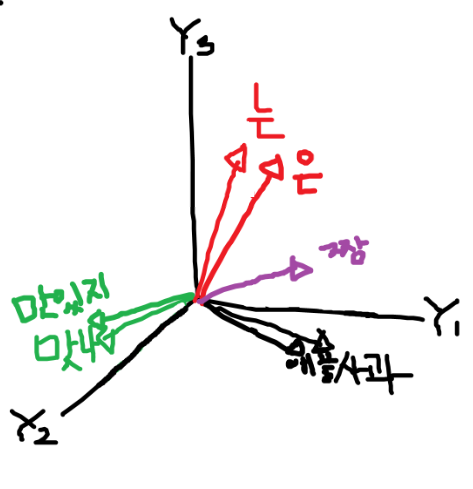

- 토큰의 ID를 입력으로 넣는 것과, 임베딩 벡터를 거친 값을 입력으로 넣는 것.. 어느것이 더 성능이 더 잘나올지 예측이 됩니다.

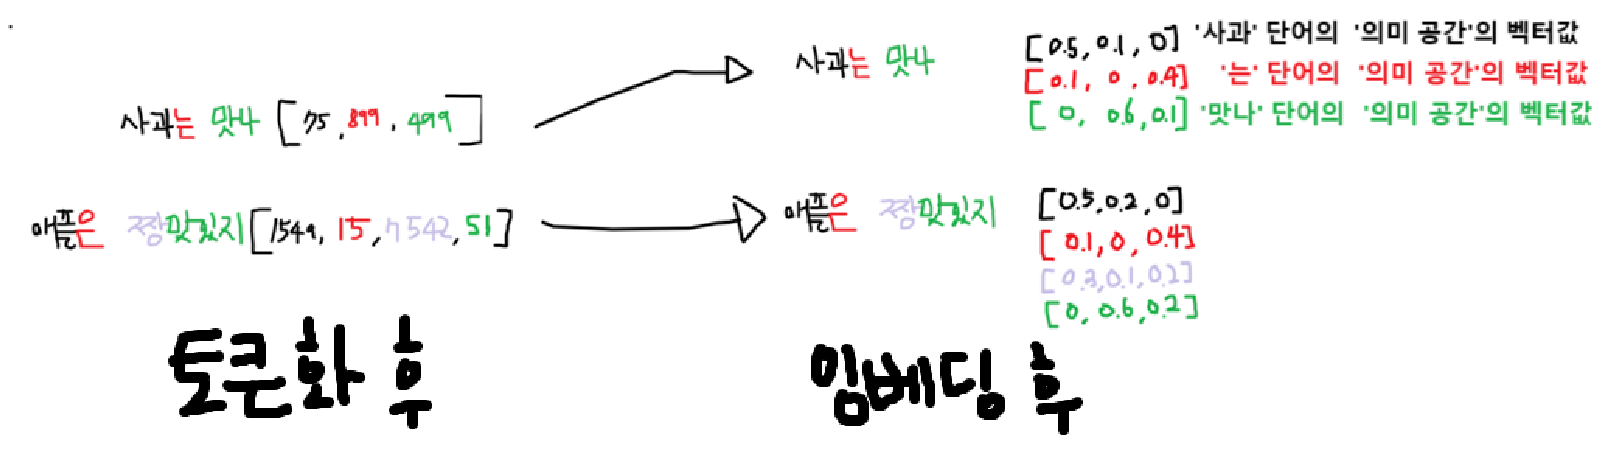

# 8. 임베딩 후 Pooling하기
- Pooling(풀링)은 컴퓨터과학에서 "반복적으로 감시하다... " 이런 뜻은 아니구요. (이건 Polling)
- 그냥 **여러개 벡터값을 하나로 합체를 하는 것**을 Pooling이라고 합니다
  - N개 벡터를 하나로 합체하여 압축된 1개의 벡터로 만드는 것입니다.
  - 드래곤볼에 '퓨전'으로 비유할 수 있겠습니다.

<br/>

- 아래는 "사과는 맛나"를 토큰화 하여 ID값만 출력한 예시입니다.

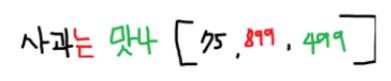

- 각 토큰을 임베딩모델을 통해, 벡터화를 하면 다음과 같이 Output이 3개의 벡터로 나옵니다

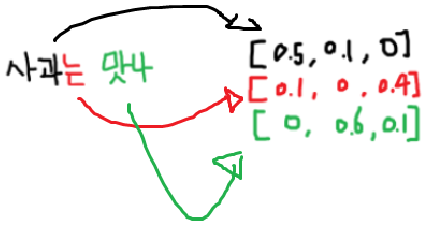

- 임베딩모델을 거쳐, 본 모델에 입력으로 넣을 것은 "문장"의 벡터 값입니다.
  - 따라서 3개의 벡터를 다시 1개로 합체해줘야합니다. Pooling!
  - 합체할때는 보통 평균으로 합체를 많이 사용합니다. **Mean Pooling** 이라고 합니다

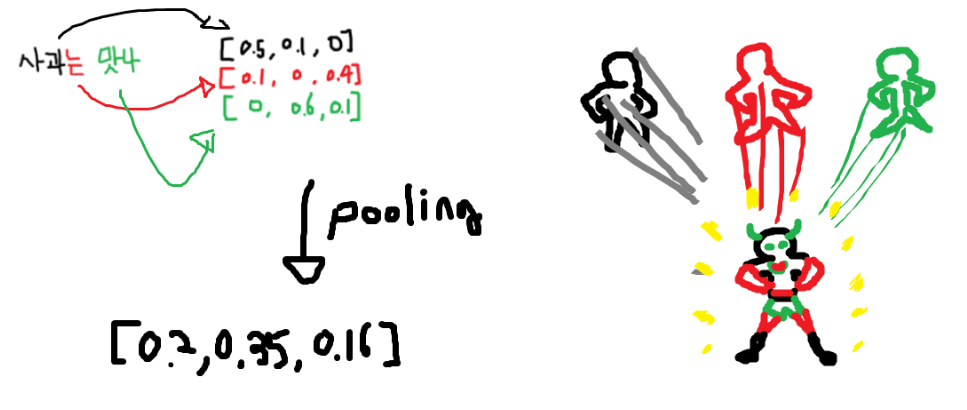

# 9. 임베딩 모델 사용 사례
### 댓글 문장으로 '좋아요' / '싫어요' 분류하기
- 임베딩 모델이 필요한 상황을 이해해봅시다.
  - 드디어 토크나이저를 사용하여, 문장을 모델의 입력으로 넣을 수 있게 되었습니다.
    - 문장을 수 List로 변환할 수 있거든요.

  - 이런 모델을 만들고자합니다. 감정 판별기!
    - 누군가 댓글을 남기면, 그 댓글이 긍정 댓글인지 부정 댓글인지 구분하는 모델입니다.
    - (부정 댓글이 달리면 빨리 삭제하려구요 ^^)

  - 만든 모델에 이런 문제가 생겼습니다. **같은 의미의 단어를 조금만 바꿔도 추론 성능이 떨어지는 겁니다.**
    - "나 이 영화 본 것 좋아요. ㅎㅎ" 댓글 -> 긍정
    - "저 이 Movie 본 것 좋아요. ^^" 댓글 -> 부정

  - 이 문제를 해결하는 방법이 바로 '임베딩 모델' 입니다.
    - 단어의 유사성을 이해할 수 있도록 해주는 모델입니다.

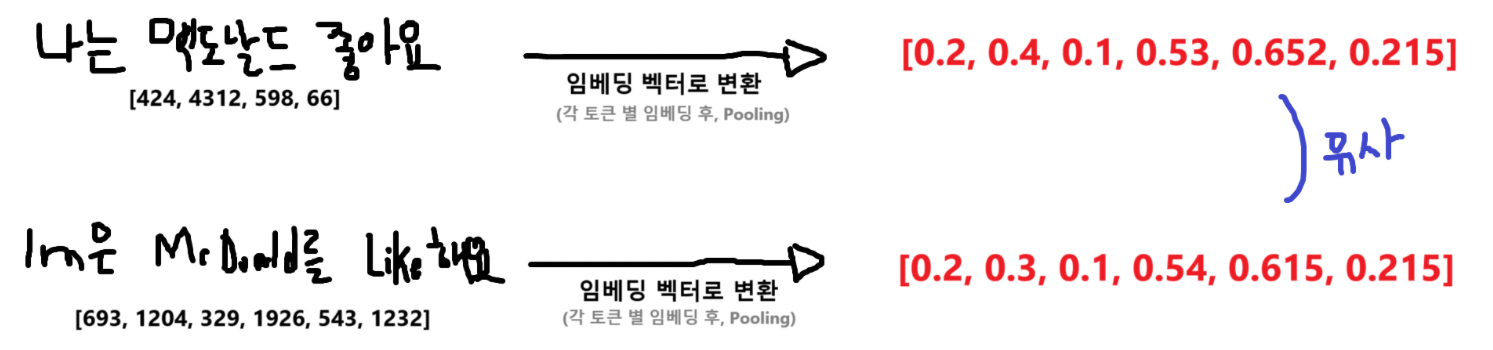

- 그래서 임베딩 모델을 도입했습니다!
  - 먼저 "나는 맥도날드가 좋아요" 라는 입력데이터를 토큰화합니다.
    - "나는 맥도날드가 좋아요" ----> [424, 4312, 598, 66]
  - 이후에 임베딩 모델을 거쳐, 벡터값을 만들어냅니다.
    - [424, 4312, 598, 66] ----> [0.2, 0.4, 0.1, 0.53, 0.652, 0.215]
  - 이렇게 만들어진 벡터와 Label(긍정)을 모델에 넣어 학습을 시작합니다.

  <br/>
  
  - 이후에 이런 문자열이 입력되었다고 가정합니다.
    - "Im은 McDonald를 Like해요." ----> [693, 1204, 329, 1926, 543, 1232]
  - 이후 임베딩 모델을 거치면, 아까와 비슷한 벡터값이 만들어집니다!!
    - [693, 1204, 329, 1926, 543, 1232] -----> [0.2, 0.3, 0.1, 0.54, 0.615, 0.215]
  - 이렇게 되면 학습 했었던 (긍정) 이라는 기댓값이 나올 확률이 더 커집니다.

### 임베딩 모델, 자주 쓰나요?
- **네, 항상 씁니다.** 2018년 이후의 모든 LLM 은 임베딩 모델을 사용을 한다고 해도 과언이 아닙니다!

# 8. 임베딩 벡터 사용해보기

- "intfloat/e5-small-v2" 라는 임베딩모델을 사용해보겠습니다.
  - https://huggingface.co/intfloat/e5-small-v2
  - 이 모델로 선정한 이유는, 다운로드하는 모델 용량 대비 성능이 잘나와서 입니다~.
    - 영어만 성능이 잘나옵니다. 한글도 성능 잘 나오는 모델들은 용량이 너무 커요.

- 아래 코드에서는 '토크나이저' 관련 파일을 다운로드 받은 후에 '모델'을 다운
받습니다.
- 모델을 다운로드 받을 때, 경고가 뜰 수 있는데, 가볍게 무시해줍시다.

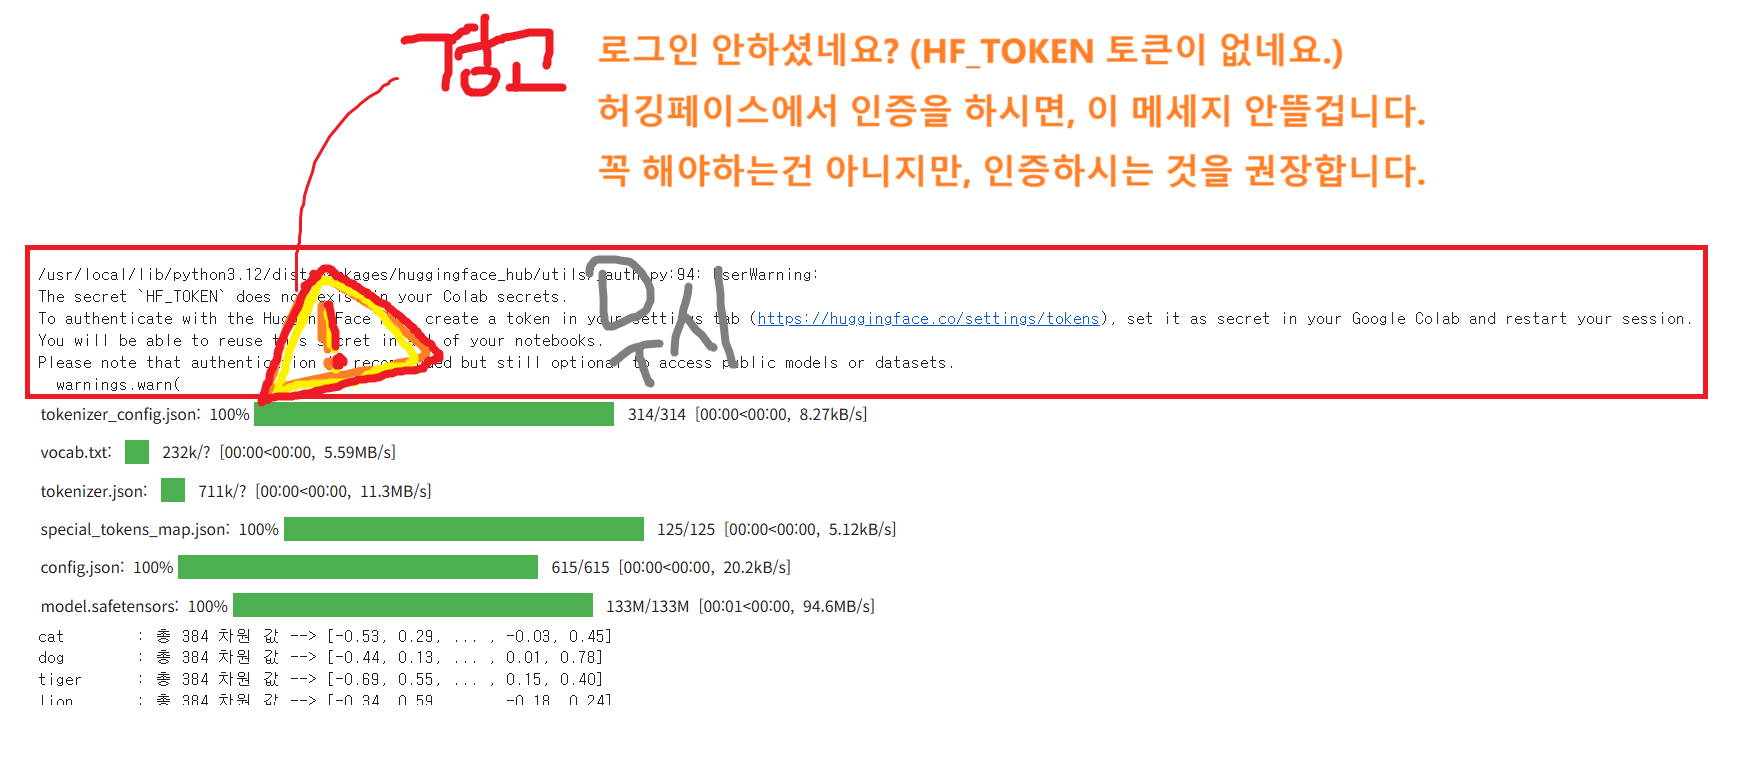

- 아래 코드를 모두 이해해주세요!
- 제대로 실행이 안되면 RUN 버튼을 한번 더 눌러주셔야합니다.
  - 모델이 용량이 크면, 다운로드 기다리다가 코랩이 실행을 끊더라구요.
  - 심지어 Runtime 연결이 끊길수도 있습니다. 그러면 처음부터 다시 다운로드를 해야해요.
  - 한번 다운로드 되고, Runtime 연결 안끊기면 빠르게 실행 될겁니다.

In [17]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# 임베딩 테스트 할 단어들
words = [
    'cat', 'dog', 'tiger', 'lion', 'wolf', 'fox', # 동물
    'apple', 'banana', 'grape', 'orange', 'peach', 'strawberry', # 과일
    'car', 'bus', 'train', 'bicycle', 'airplane', 'ship' # 탈것
]

# 토크나이저 다운로드
tokenizer = AutoTokenizer.from_pretrained("intfloat/e5-small-v2")

# 모델 다운로드
model = AutoModel.from_pretrained("intfloat/e5-small-v2") # 약 130MB

# 토큰화
#   - padding=True : 출력되는 토큰 개수를 같은 개수로 통일 (빈 공간은 0으로 채움)
#                    모델에 입력될 때, 데이터별 입력 개수가 모두 동일해야하기 때문
#   - return_tensors='pt' : PyTorch의 Tensor로 결과 리턴하시오. (텐서플로우의 Tensor와 다름)
tokens = tokenizer(words, padding=True, return_tensors='pt')

# 추론하기 (임베딩 해서 인덱싱한 번호를 벡터로 치환)
result = None
with torch.no_grad():
    outputs = model(**tokens) # 추론
    embeddings = outputs.last_hidden_state.mean(dim=1) # [중요] mean pooling 수행
    result = embeddings.tolist() # 결과를 Python List 타입으로 저장

# 결과 출력하기
for i in range(len(words)):
    nums = result[i]
    print(f'{words[i]:10s} : 총 {len(nums)} 차원 값 --> ', end='')
    print(f'[{nums[0]:.2f}, {nums[1]:.2f}, ... , {nums[-2]:.2f}, {nums[-1]:.2f}]')


cat        : 총 384 차원 값 --> [-0.53, 0.29, ... , -0.03, 0.45]
dog        : 총 384 차원 값 --> [-0.44, 0.13, ... , 0.01, 0.78]
tiger      : 총 384 차원 값 --> [-0.69, 0.55, ... , 0.15, 0.40]
lion       : 총 384 차원 값 --> [-0.34, 0.59, ... , -0.18, 0.24]
wolf       : 총 384 차원 값 --> [-0.46, 0.46, ... , 0.03, 0.29]
fox        : 총 384 차원 값 --> [-0.36, 0.31, ... , 0.08, 0.30]
apple      : 총 384 차원 값 --> [-0.36, 0.48, ... , -0.07, 0.61]
banana     : 총 384 차원 값 --> [-0.71, 0.38, ... , -0.09, 0.35]
grape      : 총 384 차원 값 --> [-0.37, 0.35, ... , -0.01, 0.26]
orange     : 총 384 차원 값 --> [-0.42, 0.17, ... , -0.02, 0.39]
peach      : 총 384 차원 값 --> [-0.60, 0.31, ... , -0.16, 0.57]
strawberry : 총 384 차원 값 --> [-0.37, 0.20, ... , 0.24, 0.43]
car        : 총 384 차원 값 --> [-0.30, 0.60, ... , -0.21, 0.44]
bus        : 총 384 차원 값 --> [-0.25, 0.27, ... , -0.36, 0.52]
train      : 총 384 차원 값 --> [-0.37, 0.25, ... , 0.09, 0.06]
bicycle    : 총 384 차원 값 --> [-0.27, 0.66, ... , -0.03, 0.40]
airplane   : 총 384 차원 값 --> [-

# 9. 임베딩 벡터 시각화
- Plotly Library로 시각화를 합니다
  - Matplot, Seaborn과 다르게 Plotly로 만든 차트는 코랩에서 마우스로 휙휙 제어가 가능합니다.

- 시각화를 위해 차원 축소가 필요합니다.
  - 2차원 데이터 : 시각화 가능
  - 3차원 데이터 : 시각화 가능
  - 4차원 데이터 : 시각화 불가
  - 지금 시각화 하려는 데이터는 384차원 데이터입니다 ^^;

- 머신러닝 알고리즘 중 차원축소(PCA)가 있습니다.
  - 3차원을 2차원으로 축소하려면 빛을 바닥에 투영(그림자 처럼)하는 값을 취하는 원리와 같습니다.
  - PCA 알고리즘으로 384차원 --> 3차원 변경 후, 차트로 출력합니다.
  - 인간의 머리로 384차원 벡터를 시각화할 수 없어서, 그림자로 구경한다고 보시면 되겠습니다.

In [23]:
# 로컬에서는 설치 필요. 최초 1번 실행
#!pip install plotly

# 위 코드를 실행 후에, 아래 코드를 실행해주세요.
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# ================================================
# 1. 입력 데이터
# ================================================
words = [
    'cat', 'dog', 'tiger', 'lion', 'wolf', 'fox',                # Animal (0)
    'apple', 'banana', 'grape', 'orange', 'peach', 'strawberry', # Fruit (1)
    'car', 'bus', 'train', 'bicycle', 'airplane', 'ship'         # Vehicle (2)
]

groups = [
    0, 0, 0, 0, 0, 0,   # Animal
    1, 1, 1, 1, 1, 1,   # Fruit
    2, 2, 2, 2, 2, 2    # Vehicle
]

group_names = ["Animal","Fruit", "Vehicle"] # 그룹 이름

colors = ["royalblue", "tomato", "seagreen"] # 그룹별 점 컬러


# ================================================
# 2. 임베딩 계산
# ================================================
tokens = tokenizer(words, padding=True, return_tensors='pt')

result = None
with torch.no_grad():
    outputs = model(**tokens)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    result = embeddings.numpy()


# ================================================
# 3. PCA로 384 차원 ---> 3차원으로 축소 후 정규화
# ================================================
# PCA
pca = PCA(n_components=3)
reduced = pca.fit_transform(result)

# L2 정규화 (잠시 후에 수업합니다.)
unit_vectors = reduced / np.linalg.norm(reduced, axis=1, keepdims=True)

# ================================================
# 4. Plotly 차트 라이브러리로 시각화
#    (이 코드는 이쁘게 만드려고 한거니, 이해하지 않아도 됩니다.)
# ================================================

# 원형 만들기
theta = np.linspace(0, np.pi, 60)
phi = np.linspace(0, 2 * np.pi, 120)
theta, phi = np.meshgrid(theta, phi)
x_sphere = np.sin(theta) * np.cos(phi)
y_sphere = np.sin(theta) * np.sin(phi)
z_sphere = np.cos(theta)
sphere_points = go.Scatter3d(
    x=x_sphere.flatten(),
    y=y_sphere.flatten(),
    z=z_sphere.flatten(),
    mode='markers',
    marker=dict(size=2, color='lightblue', opacity=0.2),
    showlegend=False
)

# 점 찍기
points = []
added_groups = set()
for i, word in enumerate(words):
    g = groups[i]
    vec = unit_vectors[i]
    is_show_legend = g not in added_groups
    added_groups.add(g)

    points.append(go.Scatter3d(
        x=[vec[0]], y=[vec[1]], z=[vec[2]],
        mode="markers+text",
        marker=dict(size=5, color=colors[g]),
        text=[word],
        name=group_names[g],
        showlegend=is_show_legend,
    ))

# 추가 차트 세팅
fig = go.Figure(data=[sphere_points] + points)
fig.update_layout(
    title="3D Word Embeddings on Scatter Sphere",
    width=850, height=800,
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        camera=dict(eye=dict(x=0.9, y=0.9, z=0.9))
    ),
    showlegend=True,
    hovermode=False,
)

fig.show(renderer="browser")


gio: http://127.0.0.1:45523: Operation not supported


# 10. Cos 유사도

### 유사한 정도를 계산하는 방법 : Cos 유사도
- A 벡터 값과, B 벡터값이 유사하다는 것은 일반좌표계에서 생각하는 것과 다릅니다.
  - 2D 좌표계는 절대 위치가 중요하고, 유클리드 거리(직선 거리)가 짧으면 근처에 있는 것이죠.

- 벡터는 방향과 크기 입니다. 이 중에서 방향이 중요합니다.
  - 3차원에서 방향이 비슷하기는 쉽지만, 384 차원에서 방향이 일치하기 쉽지 않겠죠?
  - 방향만 비슷하기만 크기는 단지 스칼라배 차이일 뿐입니다.

- 두 벡터 사이의 방향 차이를 "Cos 유사도"라는 수식을 적용하면 쉽게 구할 수 있습니다.

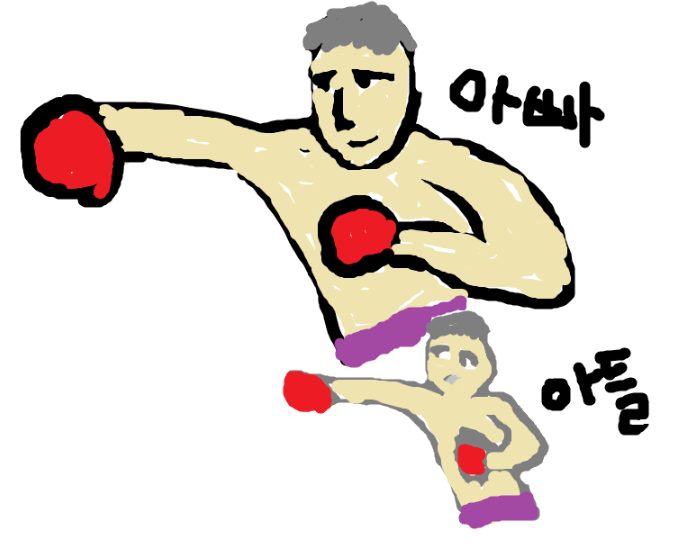

- 위 이미지에서 아빠랑 아들은 Cos유사도가 높네요.

### Cos 유사도 수식과 L2 정규화
- Cos 유사도 수식은 다음과 같습니다. (수학이 잠깐 나왔다 사라지니, 너무 걱정마세요)
  - A ⋅ B : 내적 입니다.. 계산 방법은 생략하지만, 연산 결과는 스칼라 값 1개 입니다.
  - ‖A‖ : A 행렬의 크기.. 피타고라스 정리 수식처럼 계산하면 됩니다. 연산 결과는 스칼라 값 1개
    - ‖A‖⋅‖B‖ : 스칼라 값 2개를 곱셈합니다.

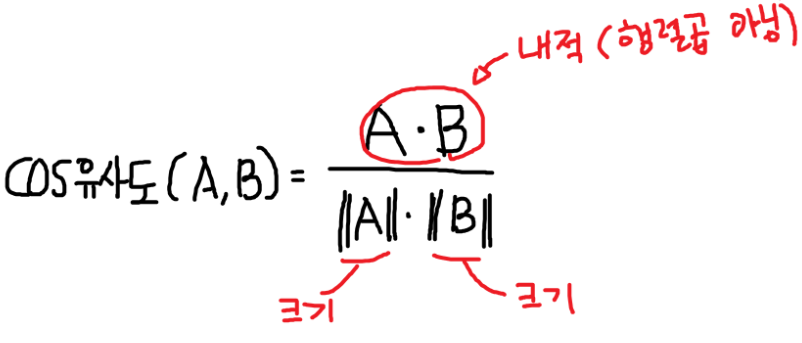

### 그런데 말입니다.
- 만약 A, B 벡터의 크기가 각각 1이라면 어떨까요?
  - ‖A‖ = 1
  - ‖B‖ = 1
- Cos유사도 계산이 엄청 쉽겠죠?
  - 그냥 Cos유사도 공식이 A⋅B 가 됩니다.

- Cos유사도는 '방향' 만으로 계산하고, '크기'는 고려하지 않는 계산법입니다.
  - 그래서 행렬의 크기가 ‖A‖ = 1 이 되도록 정규화를 하더라도, Cos유사도 계산에 지장이 없습니다.
  - Cos유사도 계산을 위해 **행렬의 크기를 1로 만들고, 방향만 남기는 것** 이것을 L2 정규화라고 합니다.


### L2 정규화 (L2 Normalization) 자주 쓰나요?
- LLM 언어 모델 : 쓰지 않습니다. 방향만 남기고, 크기 정보가 삭제되어서요.
- 이미지 검색시 : 유사성을 찾는 것이기에 사용합니다. '크기' 정보가 검색에 방해되거든요.
- 텍스트 검색시 : 유사성을 찾는 것이기에 사용합니다. '크기' 정보가 검색에 방해되거든요.
  - RAG 라는 수업에도 사용할겁니다.


### Cos 유사도 출력
- Cos 유사도로, 두 벡터간 얼마나 유사한지 값을 확인할 수 있습니다.
- L2 정규화 이후 코사인 유사도를 쉽게 계산합니다.

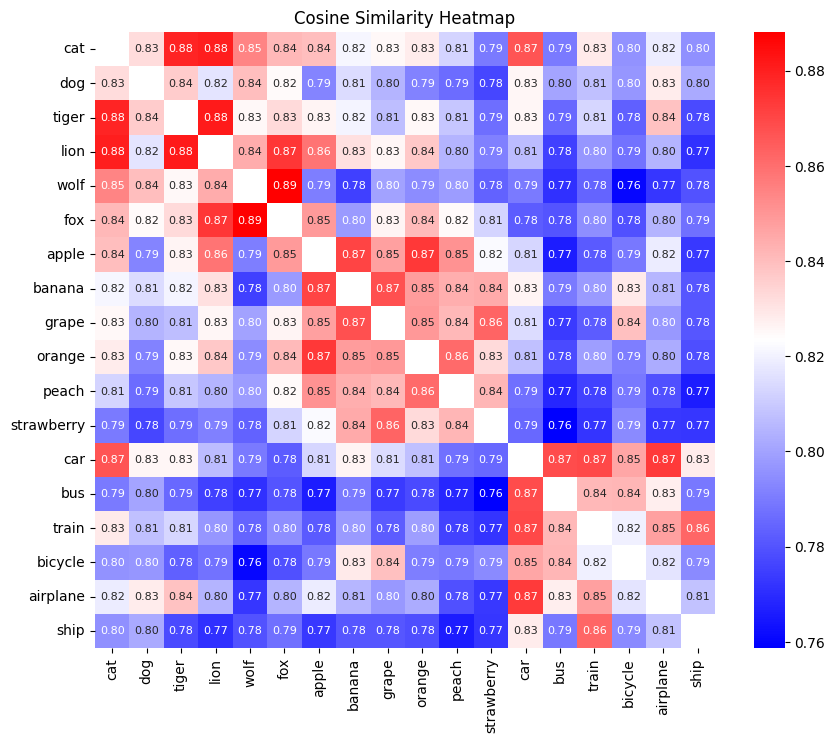

In [24]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

words = [
    'cat', 'dog', 'tiger', 'lion', 'wolf', 'fox',  # 동물
    'apple', 'banana', 'grape', 'orange', 'peach', 'strawberry',  # 과일
    'car', 'bus', 'train', 'bicycle', 'airplane', 'ship'  # 탈것
]

tokenizer = AutoTokenizer.from_pretrained("intfloat/e5-small-v2")
model = AutoModel.from_pretrained("intfloat/e5-small-v2")

tokens = tokenizer(words, padding=True, return_tensors='pt')

with torch.no_grad():
    outputs = model(**tokens)
    embeddings = outputs.last_hidden_state.mean(dim=1)  # Mean pooling

# L2 정규화 (아규먼트 설명 생략!)
embeddings = embeddings / embeddings.norm(dim=1, keepdim=True)

# 코사인 유사도 계산 (각 단어별 내적 계산, 정규화를 했으니 내적 값이 곧 유사도 값이 됩니다.)
# matmul: 벡터 내적 계산
cos_sim_matrix = torch.matmul(embeddings, embeddings.T).numpy()

# 히트맵 준비
mask = np.eye(cos_sim_matrix.shape[0], dtype=bool)
min_val = np.min(cos_sim_matrix)
max_val = np.max(cos_sim_matrix[cos_sim_matrix < 0.9])

# 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(
    cos_sim_matrix,
    xticklabels=words,
    yticklabels=words,
    cmap='bwr', # 컬러맵
    vmin=min_val, vmax=max_val, #min ~ max
    annot=True, # 숫자표시
    fmt=".2f", # 소수점 둘째 자리까지
    annot_kws={"size": 8}, # 수 폰트 크기
    mask=mask,
)

plt.title("Cosine Similarity Heatmap")
print()


- 아까 3D 원은 384 차원을 3차원으로 차원 축소해서 정확도가 많이 떨어지긴합니다.
- 그런데 이번에 Cos유사도 값은 384차원 값을, 거의 그대로 사용하여 더 정확합니다.
  - cat과 car가 유사점수가 높게 나온것이 조금 특이하네요~.
  - 의미 뿐만 아니라 글자가 비슷해도 유사도 점수가 높게 나오고 있습니다.
  - Cos유사도 값은, 수학적 특징으로 인해 대부분 0.5 ~ 0.9 정도 값을 가집니다.

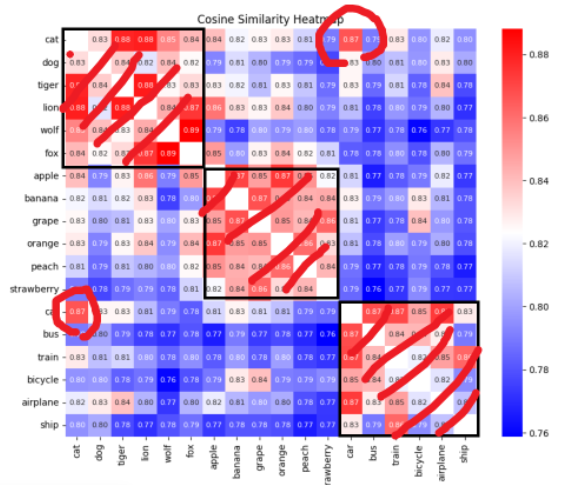

# 12. 감정 판별 모델 사용해보기
- 이번엔 허깅페이스에 올라온 "임베딩 모델" 을 한번 사용해보겠습니다.
- 임베딩 모델 중에 문자열을 긍정 or 부정으로 판별해주는 모델들이 많이 있습니다.
  - 원리는 간단합니다.
  - 긍정 / 부정 유사도 점수를 측정하여, 더 가까운 것을 출력해주면 됩니다.

- 저번 수업에서 아래 수식 기억나실까요?
  - 신경망 모델들은 아래와 같이 비선형함수가 Sequential 하게 연결된 구조 되어 있습니다. (함수 중첩 형태로)

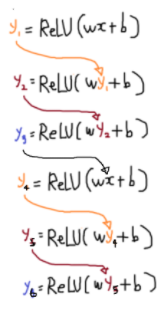

- 임베딩 모델은, '본 모델' 앞부분에 배치합니다.
  - 임베딩 모델의 출력결과가 신경망 '본 모델'의 입력으로 들어갑니다.
  - 따라서 Sequntial 하게 임베딩 모델과 '본 모델'을 연결할 수 있습니다.

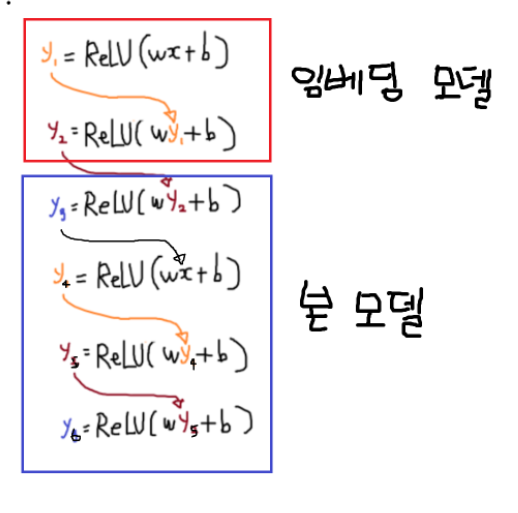

- 보통 임베딩 모델과, 본 모델은 따로따로 학습합니다.
- 다음은 '보편적인'의 모델 학습 순서입니다.
  1. 임베딩 모델 학습 시킴 (범용적으로 만듦)
  2. 학습된 임베딩 모델 뒤에 추가 레이어를 설치함 (본 모델 설치)
  3. 임베딩 모델의 파라미터는 변경되지 않도록 고정시켜둠
  4. 본 모델을 학습시킴

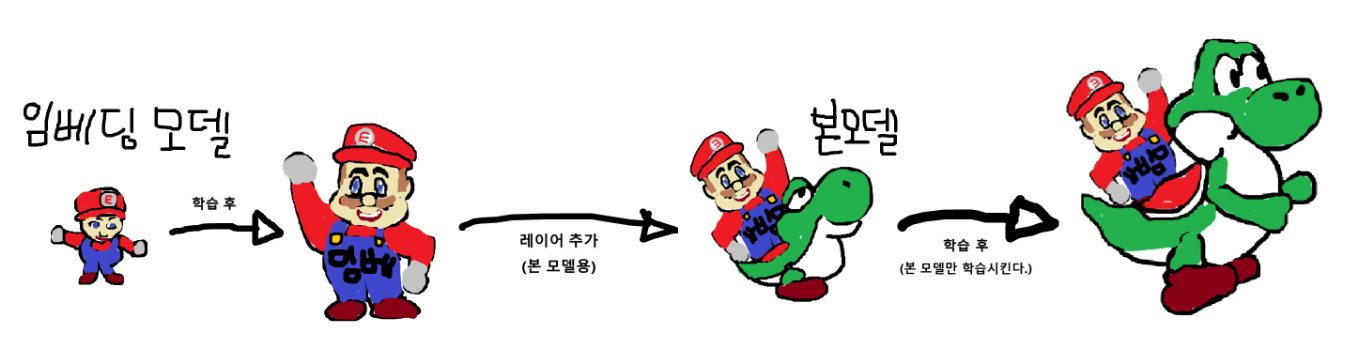

- 이제 임베딩 모델을 사용해보겠습니다.
- 우리가 사용할 임베딩 모델은 Qwen3 입니다. 비교적 최신 모델입니다.
  - https://huggingface.co/Qwen/Qwen3-Embedding-0.6B

### Qwen3 모델이란?
- Alibaba에서 개발한 대규모 언어 모델입니다.
- 가벼운데 성능이 잘 나와서 AI 연구자에게 아주 인기가 많은 모델입니다.
  - 한국어도 잘되는 편이고, 소형 장치에서도 성능이 잘 나와요.

### 사용법 두 가지
- 허깅페이스에서 제공되는 임베딩 모델은 두 가지 방법으로 주로 사용됩니다.
  1. **Transformers Library 사용하기**
    - 우리가 수업했던 방식입니다
    - Pooling 까지 직접 구현해주면 됩니다. (퓨전, 기억나시죠?)

  2. **Sentence Transformers Library** 사용하기
    - 저희가 Transformers 에서 임베딩 관련 작업을 했던 것을.. 더 쉽게 해주는 Library 입니다.
    - 대표적으로 다음 기능을 포함하고 있습니다
      - Cos 유사도 자동 계산 : 직접 계산 안해도 되어요.
      - L2 정규화 자동 적용 : 직접 계산 코드 안넣어도 되어요.
      - Pooling 자동 적용 : 직접 구현 안해도 됩니다.
      
    

- Qwen3 허깅페이스의 Model Card를 한번 읽어보세요.
  - 이번 실습은 Sentence Transformers 라이브러리로 간단하게 실습해볼게요.
  - 다음 코드는 Model Card 코드에서 조금 수정한겁니다.

### 주의
- 코랩에서 1GB 용량 모델을 다운받고 실행하는 건 쉬운일이 아닙니다.
  - 다운로드 속도가 느릴 수 있습니다.
  - 여러번 실행하면 런타임이 자주 끊겨요.
  - 해결방법은 유료결제 가 있습니다. ^^ 하지만 무료로도 인내심만 갖는다면 충분히 돌릴 수 있습니다.

In [26]:
# 로컬에서는 설치 필요. 최초 1번 실행
!pip install sentence-transformers==5.2.3

import torch
from sentence_transformers import SentenceTransformer

# 모델 로드
# 내부적으로 Transformers Library로 동작됩니다.
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B") # 다운로드 용량 : 약 1.2GB

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

In [27]:
# 모델 로드하는 코드를 실행 후, 아래 코드를 실행해야합니다.

# 질문 리스트
queries = [
    "한국의 수도는?",
    "미국의 수도는?"
]

# 유사도를 비교해볼 문서
documents = [
    "베이징",
    "Beijing",
    "부산",
    "Busan",
    "미국에 다녀왔어요.",
    "한국은 서울이 수도죠.",
    "뉴욕",
    "워싱턴DC",
    "이집트"
]

# prompt_name="qeury" : 모델에게 질문임을 알려주는 파라미터
#                       Qwen3는 어떤 종류의 문장인지 구분해주면 이해도가 더 높아집니다
query_embeddings = model.encode(queries, prompt_name="query")
document_embeddings = model.encode(documents)

# 코사인 유사도 계산하기
similarity = model.similarity(query_embeddings, document_embeddings)

# 결과 출력 : (queries X documents) 행렬
print(similarity)
print()

# 가장 큰 값의 Index가 정답
max_index = torch.argmax(similarity, dim=1).tolist()
print(max_index)
for i in range(len(queries)):
    print(f'{queries[i]} ---- {documents[max_index[i]]}')


tensor([[0.4899, 0.4696, 0.5882, 0.5870, 0.2135, 0.7468, 0.3958, 0.3983, 0.3444],
        [0.4700, 0.4711, 0.4795, 0.4330, 0.4451, 0.5492, 0.5437, 0.5699, 0.3562]])

[5, 7]
한국의 수도는? ---- 한국은 서울이 수도죠.
미국의 수도는? ---- 워싱턴DC


### 감정 판별기 만들기
- 긍정에 가까운 문장인지? 부정에 가까운 문장인지 쉽게 만들 수 있습니다.
- 여러분 관통 Project 만들때도 충분히 써먹을 수 있겠죠?

In [28]:
# 모델 로드하는 코드를 실행 후, 아래 코드를 실행해야합니다.

# 질문 리스트
queries = [
    "스토리 전개가 정말 흥미진진했어요!",
    "배우들 연기력이 대단해서 몰입됐어요.",
    "오랜만에 이렇게 재밌는 영화 봤어요.",
    "초반부터 너무 지루했어요.",
    "기대했는데 완전 실망했어요.",
    "웃기지도 않고 감동도 없어요.",
]

# 유사도를 비교해볼 문서
documents = [
    "Positive",
    "Negative",
]

# prompt_name="qeury" : 모델에게 질문임을 알려주는 파라미터
#                       Qwen3는 어떤 종류의 문장인지 구분해주면 이해도가 더 높아집니다
query_embeddings = model.encode(queries, prompt_name="query")
document_embeddings = model.encode(documents)

# 코사인 유사도 계산하기
similarity = model.similarity(query_embeddings, document_embeddings)

# 결과 출력 : (queries X documents) 행렬
print(similarity)
print()

# 가장 큰 값의 Index가 정답
max_index = torch.argmax(similarity, dim=1).tolist()
print(max_index)
for i in range(len(queries)):
    print(f'{queries[i]} ---- {documents[max_index[i]]}')


tensor([[0.2269, 0.1921],
        [0.2092, 0.1758],
        [0.3065, 0.2483],
        [0.2356, 0.3302],
        [0.2713, 0.3908],
        [0.2993, 0.3332]])

[0, 0, 0, 1, 1, 1]
스토리 전개가 정말 흥미진진했어요! ---- Positive
배우들 연기력이 대단해서 몰입됐어요. ---- Positive
오랜만에 이렇게 재밌는 영화 봤어요. ---- Positive
초반부터 너무 지루했어요. ---- Negative
기대했는데 완전 실망했어요. ---- Negative
웃기지도 않고 감동도 없어요. ---- Negative


# 13. [TIP] 프로젝트에서 백엔드를 Node.js(Express)나 Spring Boot 사용시 - AI 활용법
- AI를 하실 때 Python 말고 대안이 없습니다.
- AI 전용 서버를 따로 두고, REST API 사용하시면 됩니다.

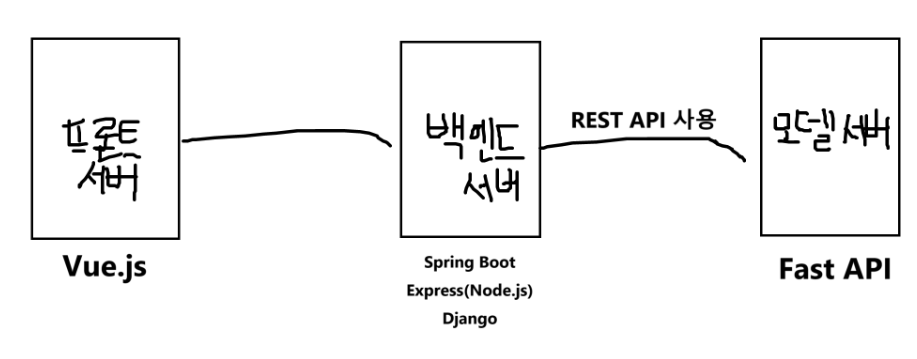

- Fast API는 타 백엔드 프레임워크를 쓸줄 안다면, 별도의 학습 없이 바로 사용 가능합니다.

```python
from fastapi import FastAPI

app = FastAPI()

@app.get("/hello/lunch")
def get_lunch():

    # 이곳에 코드를 넣습니다.

    return {"lunch": "Big-mac"}
```

# 14. 끝으로
- 이번 챕터는 내용이 길었지만, 여러분 프로젝트에 AI를 활용할 수 있는 시작 포인트가 될 것이라 생각합니다.
- 이번 챕터에서는 토크나이저에 대해 이해하고, 임베딩 모델에 대해 이해했습니다.
- 나만의 모델을 만드시고자 할때, 여러가지 토크나이저와 임베딩 모델을 바꿔가면서 실험하여 더 좋은 성능의 모델을 만들 수 있겠죠?
  - 허깅페이스에 있는 것 중 "다운로드 수 많은 모델" 선택해서 사용하시면 되겠습니다.

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.